# **32147009 - Maryam Saeed- Databases and Analytics**

# **SQL in R**

**Installing and Loading Required Packages**

The required R packages were installed and loaded to support SQL querying, data manipulation, and visualisation tasks. The sqldf package was used for running SQL queries on dataframes, ggplot2 for creating charts, and dplyr for data transformation and analysis operations.

In [ ]:
# Install & Load Packages
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

library(sqldf)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




**Loading Datasets into R**

All CSV datasets were imported into R as separate dataframes for analysis and querying. These datasets represent different operational areas of the NorthStar Urban Mobility system, including orders, deliveries, customers, vehicles, drivers, complaints, hubs, incidents, and app events

In [ ]:
# Load all the files
app_events  <- read.csv('/content/app_events.csv')
complaints  <- read.csv('/content/complaints.csv')
customers   <- read.csv('/content/customers.csv')
deliveries  <- read.csv('/content/deliveries.csv')
drivers     <- read.csv('/content/drivers.csv')
hubs        <- read.csv('/content/hubs.csv')
incidents   <- read.csv('/content/incidents.csv')
orders      <- read.csv('/content/orders.csv')
vehicles    <- read.csv('/content/vehicles.csv')

cat("✅ All files loaded")

[1] "✅ All files loaded"


###**SQL Queries**

**Query 1 – Total Number of Orders by Service Type**

This query calculates the total number of orders for each service type in the system. The analysis helps identify which services have the highest customer demand and supports resource planning and operational decision-making.

In [ ]:
# Total numbers of Orders
cat("======================================================\n")
cat("QUERY 1: Total numbers of Orders\n")
cat("======================================================\n")
query1 <- sqldf("
SELECT service_type,
       COUNT(*) AS total_orders
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")
print(query1)

QUERY 1: Total numbers of Orders
  service_type total_orders
1    Passenger          341
2       Parcel          308
3       Retail          297
4     Business          165
5      Medical          139


**Query 2 – Average Order Value by Booking Channel**

This query calculates the average order value for each booking channel and ranks them from highest to lowest. The analysis helps identify which booking platforms generate higher-value orders and supports revenue optimisation and marketing strategy decisions.

In [ ]:
# Average Order Value by Booking Channel
cat("======================================================\n")
cat("QUERY 2: Average Order Value by Booking Channel\n")
cat("======================================================\n")
query2 <- sqldf("
SELECT booking_channel,
       ROUND(AVG(order_value),2) AS avg_value
FROM orders
GROUP BY booking_channel
ORDER BY avg_value DESC
")
print(query2)

QUERY 2: Average Order Value by Booking Channel
  booking_channel avg_value
1             Web     93.94
2             App     91.61
3                     88.86
4           Phone     88.01
5             API     86.39


**Query 3 – Failed Deliveries by Drivers**

This query identifies the drivers with the highest number of failed deliveries by counting failed delivery records for each driver. The analysis helps detect driver performance issues and supports targeted training and operational improvement strategies.

In [ ]:
# Deliveries Failed by Drivers
cat("======================================================\n")
cat("QUERY 3: Deliveries Failed by Drivers\n")
cat("======================================================\n")
query3 <- sqldf("
SELECT driver_id,
       COUNT(*) AS failed_deliveries
FROM deliveries
WHERE delivery_status = 'Failed'
GROUP BY driver_id
ORDER BY failed_deliveries DESC
LIMIT 10
")
print(query3)

QUERY 3: Deliveries Failed by Drivers
   driver_id failed_deliveries
1       D133                 4
2       D104                 4
3       D024                 4
4       D131                 3
5       D108                 3
6       D092                 3
7       D083                 3
8       D055                 3
9       D010                 3
10      D004                 3


**Query 4 – Average Complaint Resolution Time by Severity**

This query calculates the average complaint resolution time for each severity level. The results help evaluate how efficiently complaints are resolved and identify whether high-severity issues require additional operational attention.

In [ ]:
# Average Resolution Time by Severity
cat("======================================================\n")
cat("QUERY 4: Average Resolution Time by Severity\n")
cat("======================================================\n")
query4 <- sqldf("
SELECT severity,
       ROUND(AVG(resolution_days),2) AS avg_days
FROM complaints
GROUP BY severity
ORDER BY avg_days DESC
")
print(query4)

QUERY 4: Average Resolution Time by Severity
  severity avg_days
1     High    13.12
2      Low     6.56
3   Medium     6.17


**Query 5 – Complaint Analysis by Type with Avg Resolution Days**

This query analyses complaints by category by calculating the total number of complaints, average resolution time, and average compensation amount for each complaint type. The analysis helps identify the most common customer issues and supports improvements in complaint handling efficiency and service quality

In [ ]:
# Complaints by Type with Avg Resolution Days
cat("===========================================================\n")
cat("QUERY 5: Complaints by Type with Average Resolution Days\n")
cat("===========================================================\n")
query5 <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total,
         ROUND(AVG(resolution_days), 2) AS avg_resolution_days,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total DESC
")
print(query5)

QUERY 5: Complaints by Type with Average Resolution Days
     complaint_type total avg_resolution_days avg_compensation
1             Delay   101                7.26            18.05
2      MissedPickup    64                7.64            22.59
3          AppIssue    53                8.60            19.61
4   DriverBehaviour    51                8.16            21.15
5 SupportExperience    20                7.45            17.13
6           Billing    16                7.75            23.87
7            Damage    15               11.33            23.98


**Query 6 – Delivery Failures by Vehicle Maintenance Status**

This query analyses the relationship between vehicle maintenance condition and delivery failures. It calculates the total deliveries, failed deliveries, and failure rate percentage for each maintenance status category. The analysis helps identify whether poorly maintained vehicles contribute to higher delivery failure rates and supports fleet maintenance planning.

In [ ]:
# Vehicle maintenance vs delivery failures
cat("===========================================================\n")
cat("QUERY 6: Delivery Failures by Vehicle Maintenance Status\n")
cat("===========================================================\n")
query6 <- sqldf("
  SELECT v.maintenance_status,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.maintenance_status
  ORDER BY failure_rate_pct DESC
")
print(query6)

QUERY 6: Delivery Failures by Vehicle Maintenance Status
  maintenance_status total_deliveries failed failure_rate_pct
1           InRepair              254     77            30.31
2             Active              542     45             8.30
3          Scheduled              154     10             6.49


**Query 7 – Average Customer Rating by Service Type**

This query calculates the average customer rating and total number of deliveries for each service type. The analysis helps compare customer satisfaction across services and identify which service categories perform better in terms of customer experience and delivery quality.

In [ ]:
# Average Customer Rating by Service Type
cat("===========================================================\n")
cat("QUERY 7: Average Customer Rating by Service Type\n")
cat("===========================================================\n")
query7 <- sqldf("
  SELECT o.service_type,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
         COUNT(*) AS total_deliveries
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY avg_rating DESC
")
print(query7)

QUERY 7: Average Customer Rating by Service Type
  service_type avg_rating total_deliveries
1       Parcel       3.90              230
2       Retail       3.87              224
3    Passenger       3.85              262
4     Business       3.85              126
5      Medical       3.84              108


# **R Analytics**

**Statistical Summary and Correlation Analysis**

This section provides statistical summaries of important operational variables such as driver ratings, customer loyalty scores, and complaint resolution days using measures including minimum, median, mean, and quartiles. It also analyses the correlation between driver ratings and training scores to evaluate whether better-trained drivers achieve higher performance ratings. These insights support performance evaluation and operational decision-making within the NorthStar Urban Mobility system.

In [ ]:
# Statistical Summary
cat("\nDriver Rating Summary:\n")
print(summary(drivers$driver_rating))

cat("\nCustomer Loyalty Score Summary:\n")
print(summary(customers$loyalty_score))

cat("\nComplaint Resolution Days Summary:\n")
print(summary(complaints$resolution_days))

# Correlation
cat("\nCorrelation - Driver Rating vs Training Score:\n")
cat(round(cor(drivers$driver_rating, drivers$training_score, use = "complete.obs"), 4), "\n")


Driver Rating Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 

Customer Loyalty Score Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 

Complaint Resolution Days Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.750   7.000   7.928  11.000  25.000 

Correlation - Driver Rating vs Training Score:
-0.0699 


**Complaint Resolution Days by Severity**

This boxplot visualises the distribution of complaint resolution days across different severity levels. The chart helps identify variations, outliers, and differences in resolution time between low, medium, and high-severity complaints, supporting evaluation of complaint handling efficiency and service responsiveness.

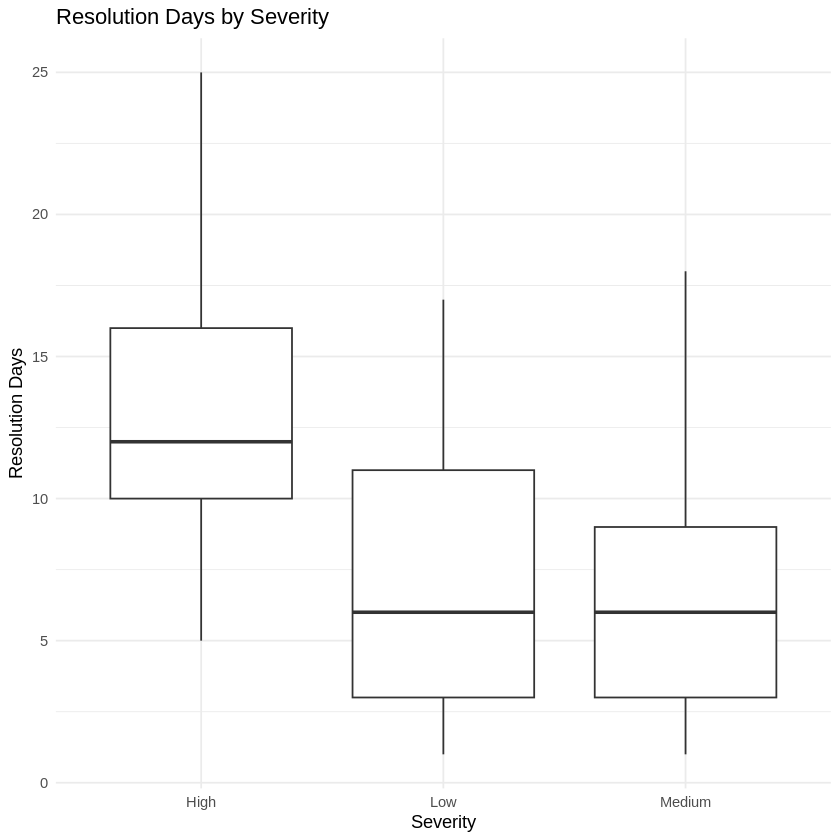

In [ ]:
# Complaint Resolution Days by Severity
ggplot(complaints, aes(x = severity, y = resolution_days)) +
  geom_boxplot() +
  labs(title = "Resolution Days by Severity",
       x = "Severity",
       y = "Resolution Days") +
  theme_minimal()

###**Data visualisation**

**Query 1 Chart - Total numbers of Orders**

This chart illustrates how total orders are distributed among various service types.

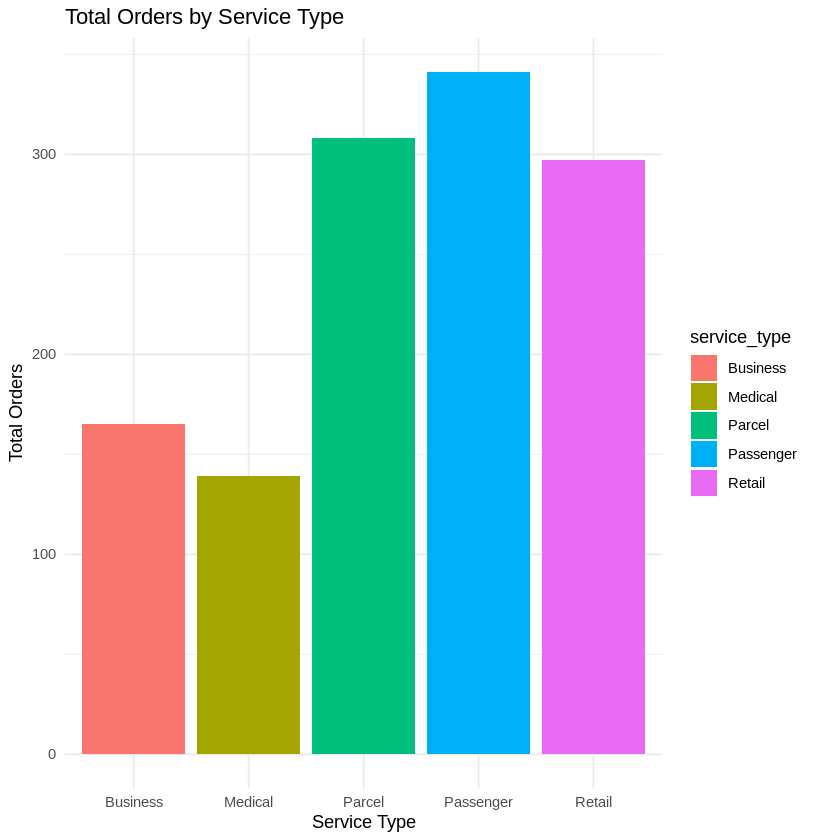

In [ ]:
# Query 1 Chart - Total numbers of Orders
ggplot(query1, aes(x = service_type, y = total_orders, fill = service_type)) +
  geom_bar(stat = "identity") +
  labs(title = "Total Orders by Service Type",
       x = "Service Type",
       y = "Total Orders") +
  theme_minimal()

**Query 2 Chart - Average Order Value by Booking Channel**

This chart illustrates the average order value through various booking channels.

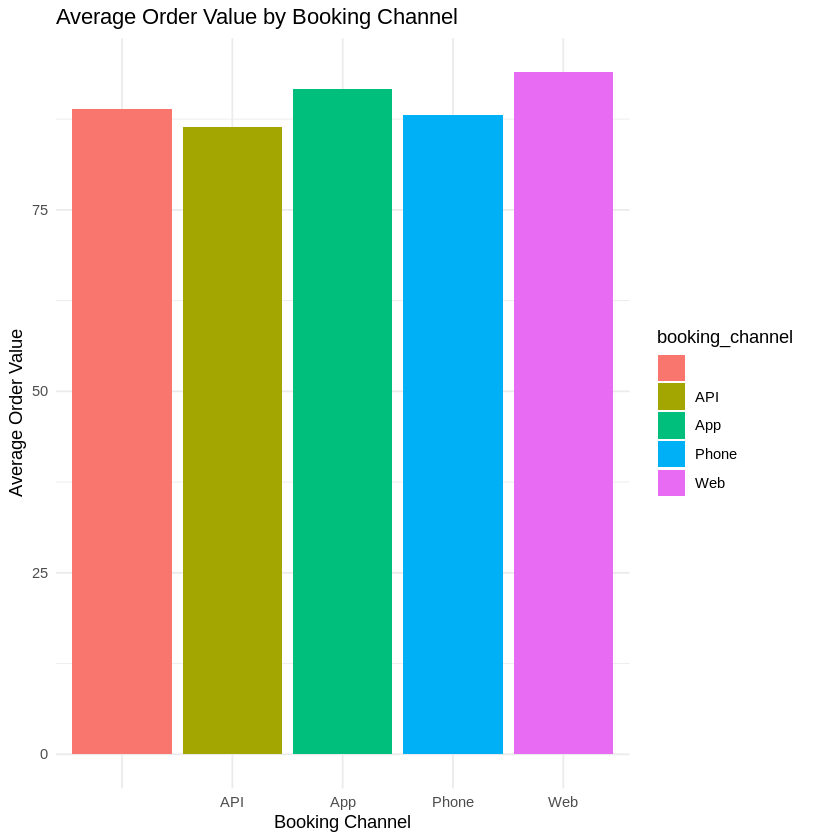

In [ ]:
# Query 2 Chart - Average Order Value by Booking Channel
ggplot(query2, aes(x = booking_channel, y = avg_value, fill = booking_channel)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Order Value by Booking Channel",
       x = "Booking Channel",
       y = "Average Order Value") +
  theme_minimal()

**Query 3 Chart - Deliveries Failed by Drivers**

This chart displays the drivers with the most failed deliveries

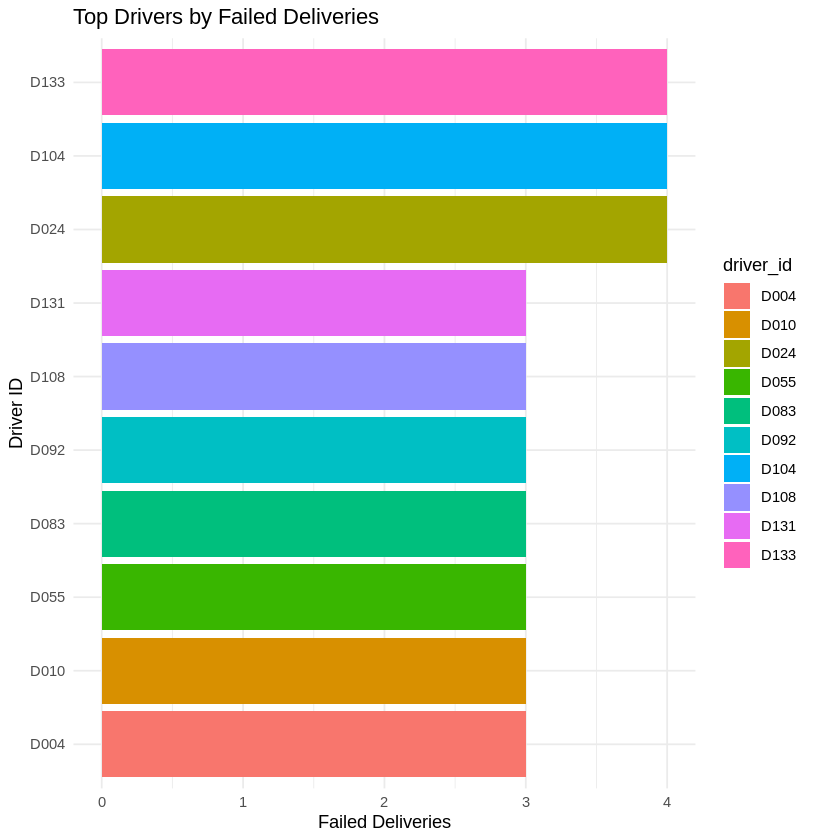

In [ ]:
# Query 3 Chart - Deliveries Failed by Drivers
ggplot(query3, aes(x = reorder(driver_id, failed_deliveries),
                   y = failed_deliveries,
                   fill = driver_id)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top Drivers by Failed Deliveries",
       x = "Driver ID",
       y = "Failed Deliveries") +
  theme_minimal()

**Query 4 Chart - Average Resolution Time by Severity**

This chart shows the average time taken to resolve complaints categorized by severity levels.

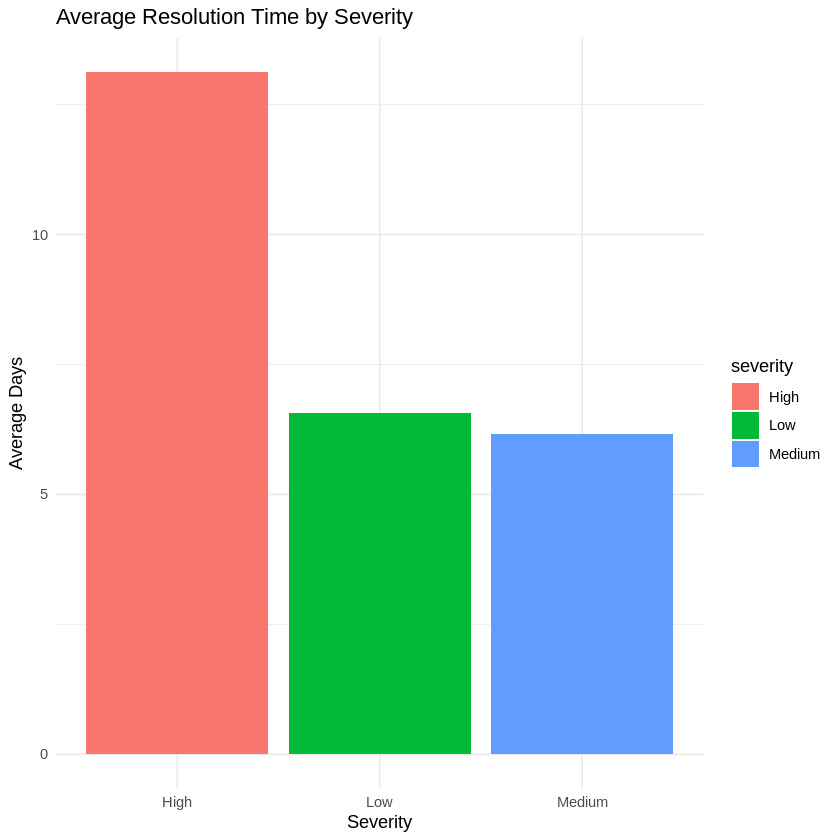

In [ ]:
# Query 4 Chart - Average Resolution Time by Severity
ggplot(query4, aes(x = severity, y = avg_days, fill = severity)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Resolution Time by Severity",
       x = "Severity",
       y = "Average Days") +
  theme_minimal()

**Query 5 Chart - Complaints by Type with Average Resolution Days**

This chart illustrates the breakdown of complaints based on type, including their average resolution duration and compensation sum.

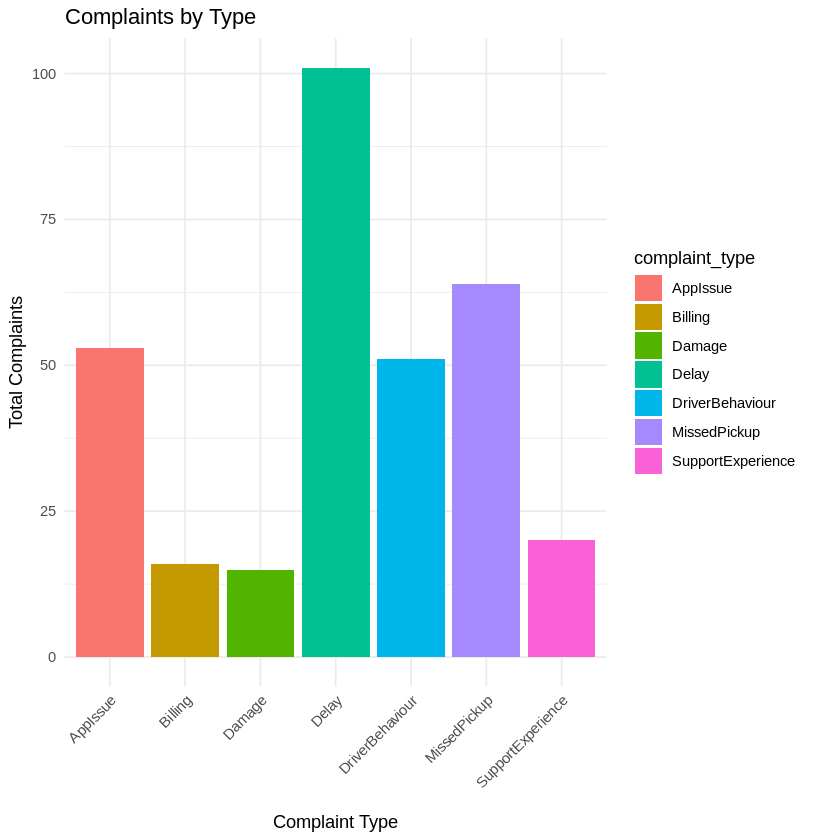

In [ ]:
# Query 5 Chart - Complaints by Type with Average Resolution Days
ggplot(query5, aes(x = complaint_type, y = total, fill = complaint_type)) +
  geom_bar(stat = "identity") +
  labs(title = "Complaints by Type",
       x = "Complaint Type",
       y = "Total Complaints") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Query 6 Chart - Delivery Failures by Vehicle Maintenance Status**

This chart illustrates the rate of delivery failures according to the status of vehicle maintenance.

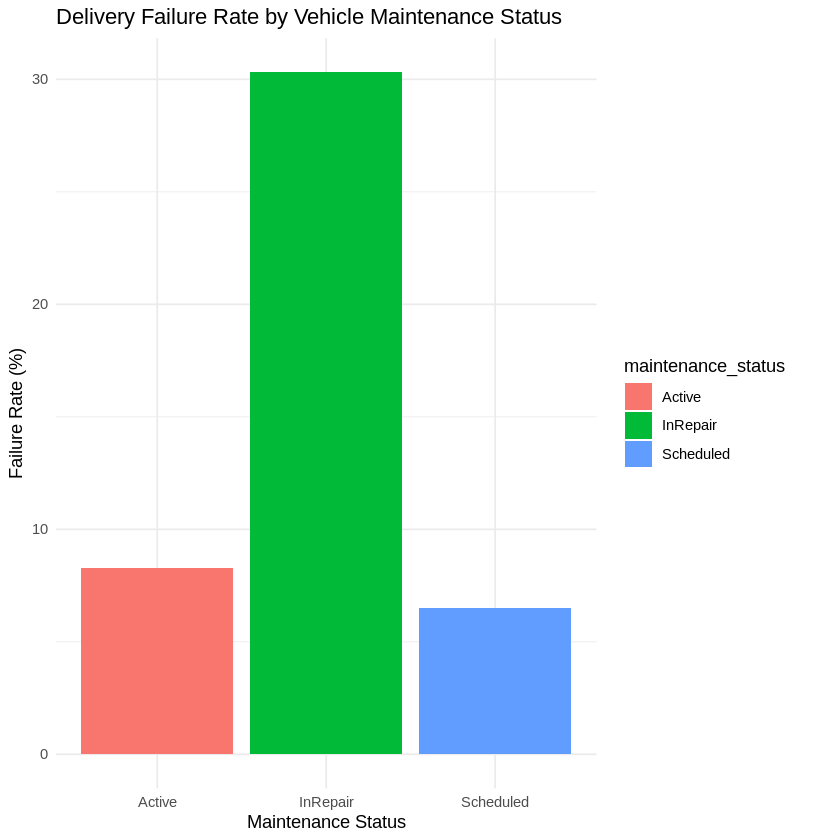

In [ ]:
# Query 6 Chart - Delivery Failures by Vehicle Maintenance Status
ggplot(query6, aes(x = maintenance_status, y = failure_rate_pct, fill = maintenance_status)) +
  geom_bar(stat = "identity") +
  labs(title = "Delivery Failure Rate by Vehicle Maintenance Status",
       x = "Maintenance Status",
       y = "Failure Rate (%)") +
  theme_minimal()

**Query 7 Chart - Average Customer Rating by Service Type**

This chart displays the average customer rating per service type as well as the overall count of deliveries.

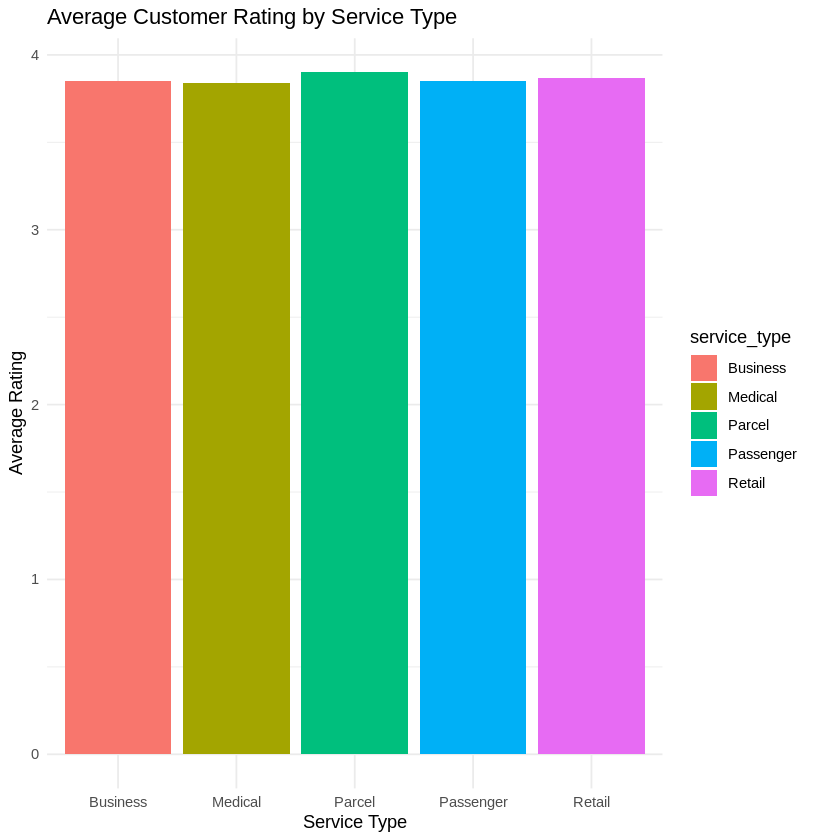

In [ ]:
# Query 7 Chart - Average Customer Rating by Service Type
ggplot(query7, aes(x = service_type, y = avg_rating, fill = service_type)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Customer Rating by Service Type",
       x = "Service Type",
       y = "Average Rating") +
  theme_minimal()